In [7]:
import zipfile
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
plt.style.use(['default', 'science', 'no-latex'])

from code_utils.utils_basic import PROJECT_PATH, PROJECTED_CRS

In [8]:
def load_csv_from_zip(zip_path, csv_path, **kwargs):
    """
    Load a CSV file from a ZIP archive into a pandas DataFrame.
    """
    with zipfile.ZipFile(zip_path, 'r') as zf:
        with zf.open(csv_path) as f:
            df = pd.read_csv(f, **kwargs)
    return df
# ============================================================

In [9]:
# Load zone
file_path = (
    (PROJECT_PATH / 'data/planning_area.zip').as_posix() +
    '!planning_area.geojson'
)
zone = gpd.read_file(file_path)
if zone.crs.equals(PROJECT_PATH):
    zone = zone.to_crs(PROJECTED_CRS)


# Load bus stop tap-in passenger volume data
data = load_csv_from_zip(
    zip_path = PROJECT_PATH / 'data/features.zip',
    csv_path = 'busstop_volume_workday.csv',
    dtype = {'pt_code': str},
    index_col = None, header = 0,)
# Convert
data['pt_code'] = data['pt_code'].str.zfill(5)

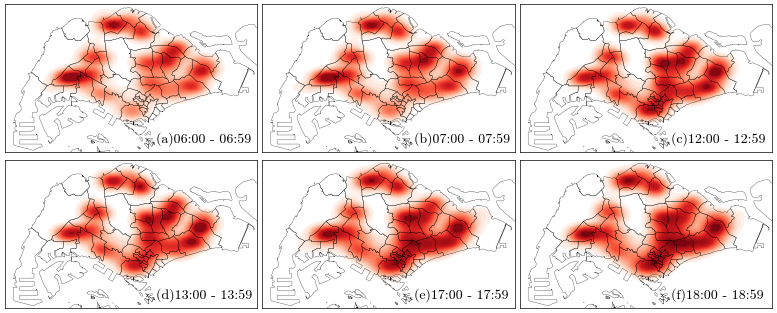

In [10]:
hour = '07'
hour_li = [
    '06', '07',
    '12', '13',
    '17', '18'
]
# hour_li = [
#     '06', '07', '10',
#     '12', '13', '15',
#     '17', '18', '20'
# ]

fig, axes = plt.subplots(2, 3, figsize=(9.9, 4.0), sharex=True, sharey=True,)
# fig, axes = plt.subplots(3, 3, figsize=(9.9, 6.0), sharex=True, sharey=True,)
axes = axes.flatten()


for i, hour in enumerate(hour_li):
    ax = axes[i]

    # Plot zone boundary
    ax = zone.boundary.plot(
        edgecolor = 'black',
        linewidth = 0.2,
        ax = ax
    )

    # Plot bus stop volume,
    ax = sns.kdeplot(data = data,
        x = 'proj_x', y = 'proj_y', weights = hour,
        fill = True,
        cmap = 'Reds',
        bw_adjust = 0.60,
        alpha = 1.0,
        levels = 30,
        ax = ax,)

    # tick params
    ax.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False,
        labelbottom=False, labelleft=False)
    ax.set_xlim([ 1000, 52000])
    ax.set_ylim([21000, 51000])
    ax.set_xlabel('')
    ax.set_ylabel('')

    # add figure caption
    ax.text(
        0.6, 0.05,
        f'({chr(97+i)}){hour}:00 - {hour}:59',
        ha = 'left', va = 'bottom',
        fontsize = 10,
        transform = ax.transAxes,
    )

# fig.tight_layout(pad=1.00, w_pad=0.00, h_pad=0.00,)
fig.subplots_adjust(
    wspace = 0.02,  # horizontal space
    hspace = 0.02   # vertical space
)

# Save figure
# fig.savefig(PROJECT_PATH / r'figures/passenger_spatial_distribution/volume_spatial_distribution.pdf',
#     bbox_inches = 'tight',
#     format = 'pdf',)
# fig.savefig(PROJECT_PATH / r'figures/passenger_spatial_distribution/volume_spatial_distribution.jpg',
#     dpi = 600, bbox_inches = 'tight')